## 2.1 Load & Inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**Findings (fill in after running):**
- Rows / columns: `df.shape`
- Numeric columns: (list from `df.info()`)
- Text/object columns: (list from `df.info()`)
- Columns with most missing values: (top of `missing` above)

⚠ Verify column names against your actual downloaded CSV — do not assume they match the guide description.

## 2.3 Cleaning & Feature Engineering 

In [6]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
before = len(df)
df = df.dropna(subset=["price_clean"])
print(f"Dropped {before - len(df)} rows without usable price. Remaining: {len(df)}")

Dropped 9684 rows without usable price. Remaining: 177847


In [7]:
import re

def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    m = re.search(r"[\d,]+\.?\d*", x)
    if not m:
        return None
    val = float(m.group().replace(",", ""))
    if "sqm" in x or "sq.m" in x or "sq m" in x:
        val *= 10.764
    return val

area_col = "Carpet Area" if "Carpet Area" in df.columns else "Super Area"
df["carpet_area_sqft"] = df[area_col].apply(parse_area)
if area_col == "Carpet Area" and "Super Area" in df.columns:
    fallback = df["Super Area"].apply(parse_area)
    df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(fallback)

before = len(df)
df = df.dropna(subset=["carpet_area_sqft"])
df = df[df["carpet_area_sqft"] > 0]
print(f"Dropped {before - len(df)} rows without usable area. Remaining: {len(df)}")

Dropped 90 rows without usable area. Remaining: 177757


In [8]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if "ground" in x:
        return 0
    if "basement" in x:
        return -1
    m = re.search(r"-?\d+", x)
    return int(m.group()) if m else None

if "Floor" in df.columns:
    df["floor_num"] = df["Floor"].apply(parse_floor)
else:
    df["floor_num"] = np.nan
df["floor_num"] = df["floor_num"].fillna(df["floor_num"].median())

In [9]:
def to_numeric_impute(col, fill=0):
    if col not in df.columns:
        df[col] = fill
        return
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median() if df[col].notna().any() else fill)

for col in ["Bathroom", "Balcony", "Car Parking"]:
    to_numeric_impute(col, fill=0)

df = df.rename(columns={"Bathroom": "bathroom", "Balcony": "balcony", "Car Parking": "car_parking"})

In [10]:
TOP_N = 50
top_locations = df["location"].value_counts().head(TOP_N).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
df["location_grouped"].nunique()

51

In [11]:
drop_cols = [c for c in ["Title", "Description", "Society", "Dimensions", "Plot Area",
                          "Amount(in rupees)", "Price (in rupees)", "Carpet Area", "Super Area",
                          "Floor", "location", "Status", "overlooking"] if c in df.columns]
# also drop columns that are almost entirely empty
mostly_empty = [c for c in df.columns if df[c].isna().mean() > 0.9]
drop_cols = list(set(drop_cols + mostly_empty))
df = df.drop(columns=drop_cols)
df.columns.tolist()

['Index',
 'Transaction',
 'Furnishing',
 'facing',
 'bathroom',
 'balcony',
 'car_parking',
 'Ownership',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'location_grouped']

In [12]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = len(df)
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
print(f"Dropped {before - len(df)} outlier rows. Remaining: {len(df)}")

Dropped 3286 outlier rows. Remaining: 174471


**Plot 1 — Price distribution (log scale)**

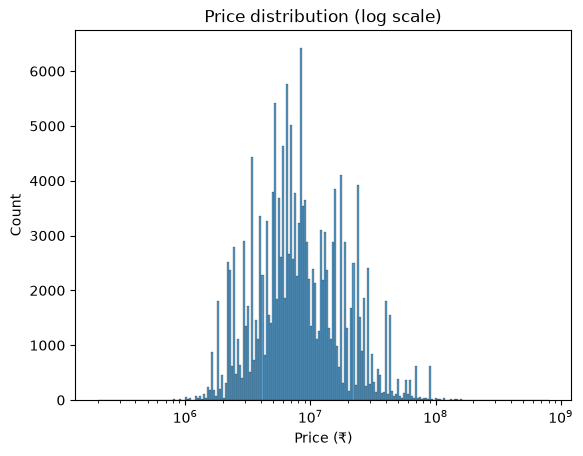

In [13]:
sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (₹)")
plt.show()

*Comment: heavily right-skewed even on log scale / roughly log-normal — typical for real-estate prices.*

**Plot 2 — Price vs. carpet area**

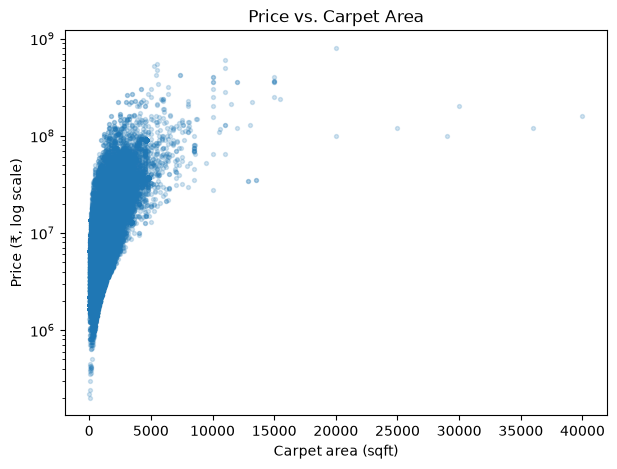

In [14]:
plt.figure(figsize=(7,5))
plt.scatter(df["carpet_area_sqft"], df["price_clean"], alpha=0.2, s=8)
plt.yscale("log")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (₹, log scale)")
plt.title("Price vs. Carpet Area")
plt.show()

*Comment: positive correlation, wide variance at every area (confirms location/other features matter too).*

**Plot 3 — Average price by top-15 locations**

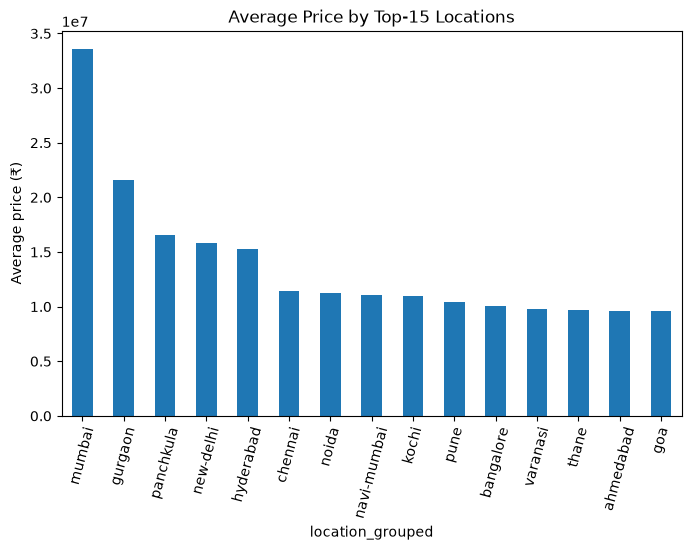

In [15]:
top15 = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(8,5))
top15.plot(kind="bar")
plt.ylabel("Average price (₹)")
plt.title("Average Price by Top-15 Locations")
plt.xticks(rotation=75)
plt.show()

*Comment: large spread across locations, confirming `location_grouped` is a strong categorical predictor.*

**Plot 4 — Price by furnishing status / bathrooms (box plots)**

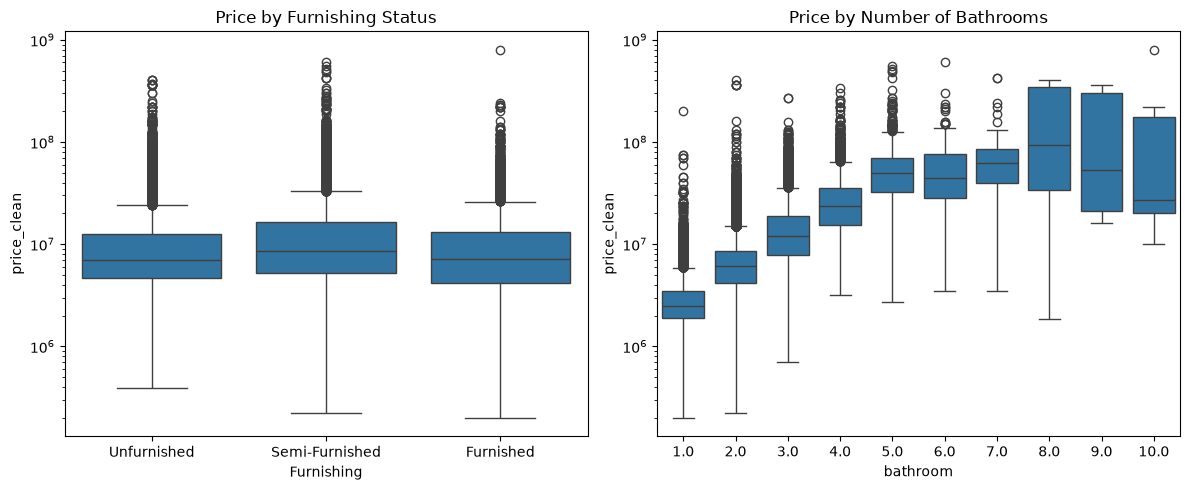

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
if "Furnishing" in df.columns:
    sns.boxplot(x="Furnishing", y="price_clean", data=df, ax=axes[0])
    axes[0].set_yscale("log")
    axes[0].set_title("Price by Furnishing Status")
sns.boxplot(x="bathroom", y="price_clean", data=df, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by Number of Bathrooms")
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = [c for c in ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]
                         if c in df.columns]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
}

fitted = {}
for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("reg", reg)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f"{name} trained.")

LinearRegression trained.
RandomForest trained.
GradientBoosting trained.
KNN trained.


In [19]:
results = []
for name, pipe in fitted.items():
    pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,model,MAE,RMSE,R2
1,RandomForest,1.021403e+06,5.275278e+06,0.850967
3,KNN,1.246834e+06,5.951652e+06,0.810300
2,GradientBoosting,3.050209e+06,6.547114e+06,0.770442
0,LinearRegression,4.538211e+06,8.430508e+06,0.619372


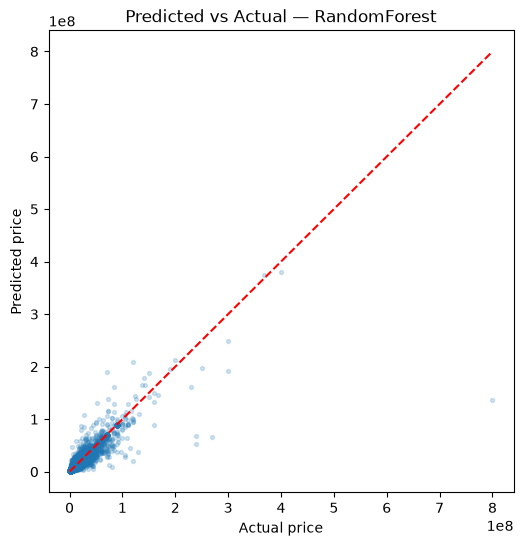

Best model: RandomForest
Furnishing ['Unfurnished', 'Semi-Furnished', 'Furnished']
Transaction ['Resale', 'New Property', 'Other', 'Rent/Lease']
Ownership ['Freehold', 'Co-operative Society', 'Power Of Attorney', 'Leasehold']
facing ['East', 'West', 'North - East', 'North', 'North - West', 'South', 'South -West', 'South - East']


In [ ]:
best_name = results_df.iloc[0]["model"]
best_model = fitted[best_name]
pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.2, s=8)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs Actual — {best_name}")
plt.show()

print(f"Best model: {best_name}")

In [23]:
import joblib
import json
import os

os.makedirs("../backend/app/models", exist_ok=True)

joblib.dump(best_model, "house_price.pkl")
joblib.dump(best_model, "../backend/app/models/house_price.pkl")

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

locations = sorted(df["location_grouped"].unique().tolist())
json.dump(locations, open("locations.json", "w"))
json.dump(locations, open("../backend/app/models/locations.json", "w"))
print(f"Saved {len(locations)} locations.")

Reloaded prediction: [7000000.]
Saved 51 locations.
